In [1]:
##This has to be ran from parent directoty otherwise functions.func does not exist 

import xarray as xr 
from functions.funcs import *
import matplotlib.pyplot as plt 

In [2]:
ds = xr.open_dataset(r"C:\FATE\Code\Data\cmems(3).nc")
ds

<xarray.Dataset> Size: 436MB
Dimensions:    (time: 1156, depth: 15, latitude: 40, longitude: 38)
Coordinates:
  * depth      (depth) float32 60B 0.494 1.541 2.646 3.819 ... 21.6 25.21 29.44
  * latitude   (latitude) float32 160B 4.5 4.583 4.667 4.75 ... 7.583 7.667 7.75
  * longitude  (longitude) float32 152B -163.8 -163.7 -163.6 ... -160.8 -160.7
  * time       (time) datetime64[ns] 9kB 2021-07-01 2021-07-02 ... 2024-08-29
Data variables:
    uo         (time, depth, latitude, longitude) float64 211MB ...
    vo         (time, depth, latitude, longitude) float64 211MB ...
    zos        (time, latitude, longitude) float64 14MB ...
Attributes:
    copernicusmarine_version:  2.2.2

In [3]:
vo  = ds['vo'] ## this is y velocity
uo = ds['uo'] ## this is x velocity

5.883611
-162.078333
<xarray.DataArray 'uo' ()> Size: 8B
[1 values with dtype=float64]
Coordinates:
    depth      float32 4B 0.494
    latitude   float32 4B 5.917
    longitude  float32 4B -162.1
    time       datetime64[ns] 8B 2021-07-03
Attributes:
    units:          m s-1
    valid_max:      4296
    long_name:      Eastward velocity
    valid_min:      -3126
    standard_name:  eastward_sea_water_velocity
    unit_long:      Meters per second


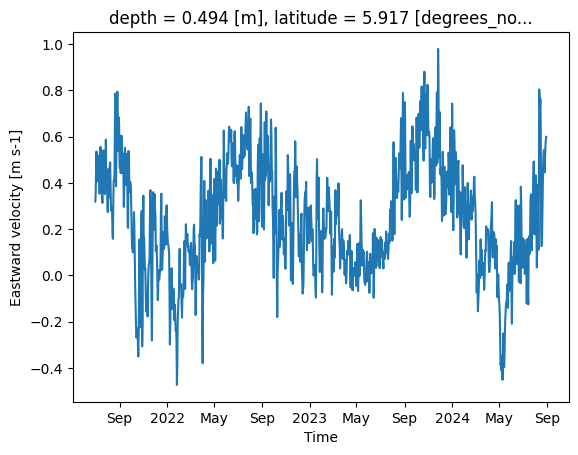

In [4]:
## plotting y velocity at palymra 
palmyra  = Palmyra_obj()
lat = palmyra.y
print(lat)
lon = palmyra.x
print(lon)

time = uo.sel(latitude = lat, longitude = lon, depth = 1, time = "2021-07-02-16.0:43.5",method = "nearest") 
print(time)
#0.319224
#0.357677
uo.sel(latitude = lat, longitude = lon, depth = 1, method = "nearest").plot()

In [5]:
## lets get time averaged x and y velocity 

vomean = vo.mean(["depth", "time"]).to_numpy()
uomean = uo.mean(["time", "depth"]).to_numpy()
latitude = ds["latitude"].to_numpy()
longitude = ds["longitude"].to_numpy()


Text(0, 0.5, 'Latitude')

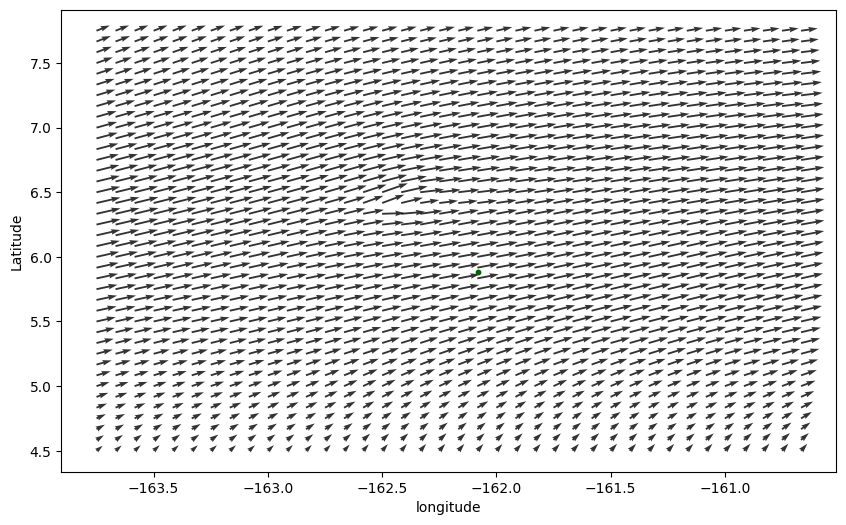

In [6]:
Xcurrents,Ycurrents = np.meshgrid(longitude, latitude)
fig,ax = plt.subplots(figsize = (10,6))
ax.quiver(Xcurrents, Ycurrents,uomean,vomean,scale = 10, alpha = 0.8)
Palmyra_plot(ax)
ax.set_xlabel("longitude")
ax.set_ylabel("Latitude")

c:\FATE\Code\functions\funcs.py:224: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)


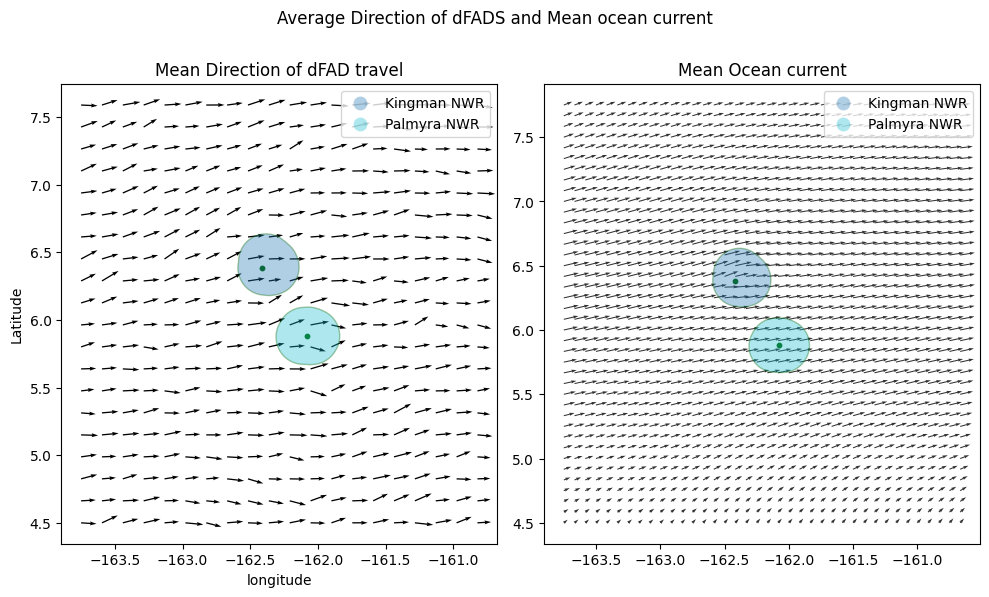

In [15]:
data = gpd.read_file(r"C:\FATE\Code\Data\Palmyra Data\MI_and_SAT_FAD_positions")
dataNWR = gpd.read_file(r"Data\Palmyra_Shapefiles",  layer = 'PAL_KING_NWR_12nm')

data, delx_list, dely_list = add_distance_collumns(data)
lat, lon = list_of_latlon(data)

fig, ax = plt.subplots(1,2, figsize = (10,6))
plotting_direction(lat, lon, delx_list=delx_list, dely_list=dely_list, ax = ax[0], scale =15, bins = 20)
ax[1].quiver(Xcurrents, Ycurrents,uomean,vomean,scale = 9, alpha = 0.8)

Palmyra_plot(ax[1])
Palmyra_plot(ax[0])
Kingmon_plt(ax[0])
Kingmon_plt(ax[1])

ax[0].set_title("Mean Direction of dFAD travel")
ax[1].set_title("Mean Ocean current")
plot_NWPs(ax[0],dataNWR)
plot_NWPs(ax[1],dataNWR)
#ax[0,0].set_xlabel("longitude")
#ax[1,0].set_ylabel("Latitude")
fig.suptitle("Average Direction of dFADS and Mean ocean current")
fig.tight_layout()
fig.savefig(r"C:\FATE\Figures\Direction_meanocean_2.png")